In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Downloads/fuel-econ.csv")
df.shape

(3929, 20)

In [3]:
df.head()

,id,make,model,year,VClass,drive,trans,fuelType,cylinders,displ,pv2,pv4,city,UCity,highway,UHighway,comb,co2,feScore,ghgScore
0,32204,Nissan,GT-R,2013,Subcompact Cars,All-Wheel Drive,Automatic (AM6),Premium Gasoline,6,3.8,79,0,16.4596,20.2988,22.5568,30.1798,18.7389,471,4,4
1,32205,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (AM-S6),Premium Gasoline,4,2.0,94,0,21.8706,26.9770,31.0367,42.4936,25.2227,349,6,6
2,32206,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,17.4935,21.2000,26.5716,35.1000,20.6716,429,5,5
3,32207,Volkswagen,CC 4motion,2013,Compact Cars,All-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,16.9415,20.5000,25.2190,33.5000,19.8774,446,5,5
4,32208,Chevrolet,Malibu eAssist,2013,Midsize Cars,Front-Wheel Drive,Automatic (S6),Regular Gasoline,4,2.4,0,95,24.7726,31.9796,35.5340,51.8816,28.6813,310,8,8


### Exercise 1: Categorical Plot
Use a plot to explore whether or not there are differences in recommended fuel type depending on the vehicle class. Only investigate the difference between the two main fuel types found in the 'fuelType' variable: Regular Gasoline and Premium Gasoline. (The other fuel types represented in the dataset are of much lower frequency compared to the main two, that they'll be more distracting than informative.) 

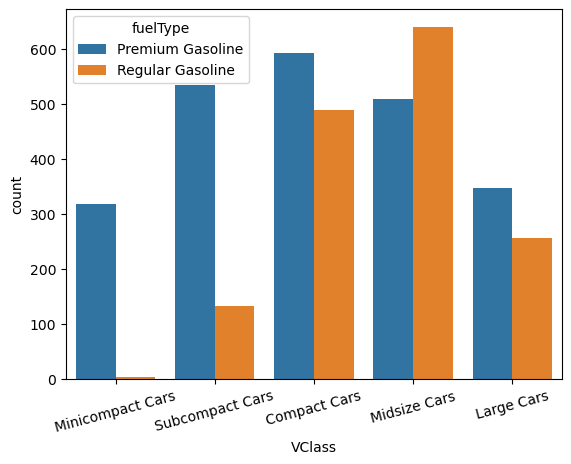

In [4]:
sedan_classes = ["Minicompact Cars", "Subcompact Cars", "Compact Cars", "Midsize Cars", "Large Cars"]
VClass = pd.CategoricalDtype(categories=sedan_classes, ordered=True)
df["VClass"] = df["VClass"].astype(VClass)

df = df[df["fuelType"].isin(["Premium Gasoline", "Regular Gasoline"])]

sns.countplot(data=df, x="VClass", hue="fuelType");
plt.xticks(rotation=15);

### Exercise 2: Facet Plot
Plot the distribution of combined fuel mileage (column 'comb', in miles per gallon) by manufacturer (column 'make'), for all manufacturers with at least eighty cars in the dataset. Consider which manufacturer order will convey the most information when constructing your final plot. 

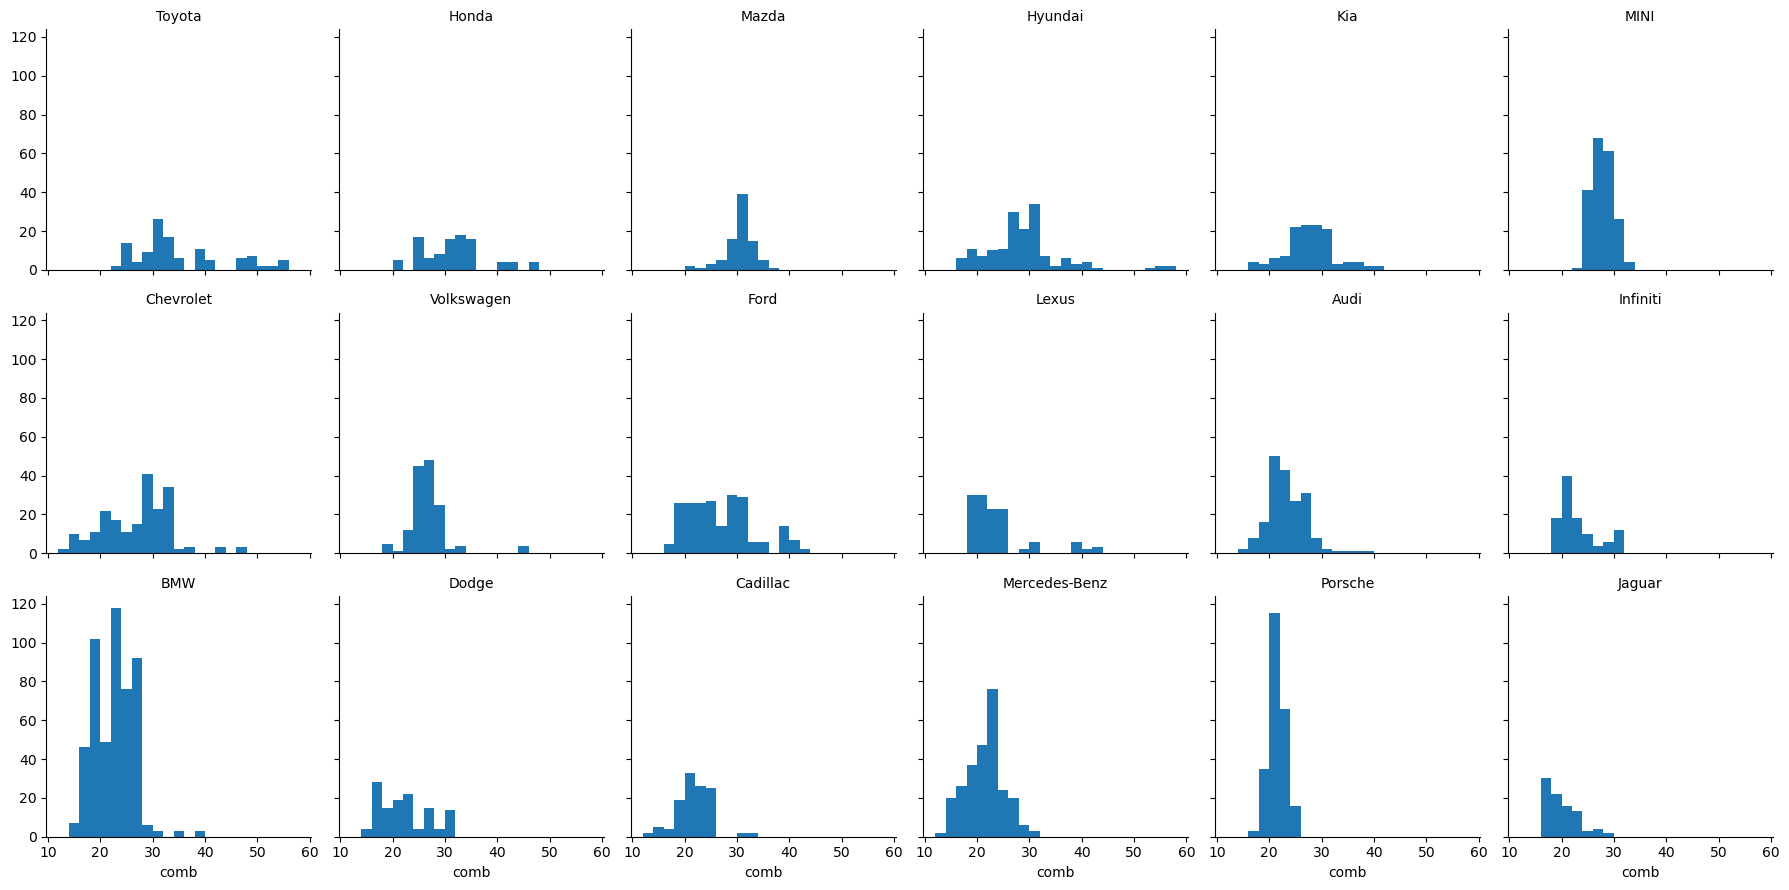

In [5]:
THRESHOLD = 80
make_frequency = df["make"].value_counts()
idx = np.sum(make_frequency > THRESHOLD)

#Indexing brands by frequency
most_makes = make_frequency.index[:idx]
#Filtered DataFrame of brands with at least 80 cars. 
sub_df = df.loc[df["make"].isin(most_makes)]

make_means = sub_df.groupby("make").mean(numeric_only=True)
#indexing brands by mean value 
comb_order = make_means.sort_values("comb", ascending=False).index

#Plot 
g = sns.FacetGrid(data=sub_df, col="make", col_wrap=6, col_order=comb_order)
g.map(plt.hist, "comb", bins=np.arange(12, sub_df['comb'].max()+2, 2))
g.set_titles("{col_name}")

### Exercise 3: Cluster plot
Continuing on from the previous task, use a bar chart to plot the mean fuel efficiency for each manufacturer with at least 80 cars in the dataset. Make sure to estimate the uncertainty by showing the standard deviation.

In [ ]:
sns.barplot(data=sub_df, x="comb", y="make", color="tab:blue", order=comb_order, errorbar="sd")
plt.xlabel()